# Extensible Pipeline --- `singledispatch` and Custom Plot Types

In R's ggplot2, the `+` operator dispatches through `ggplot_add()` / `update_ggplot()`
which are S3/S7 generics --- meaning any package can register a new method for its
own class.

In **ggplot2_py**, we use Python's `functools.singledispatch` to achieve the same
extensibility. The key generics are:

| Generic | Purpose |
|---|---|
| `update_ggplot(obj, plot)` | Add *obj* to *plot* via `+` |
| `ggplot_build(plot)` | Build the plot into computed data |
| `ggplot_gtable(built)` | Convert built data into a gtable for rendering |

Extension authors can register **any Python class** with these generics, enabling
custom plot components without modifying ggplot2_py itself.

In [1]:
%matplotlib agg
import pandas as pd
import numpy as np

np.random.seed(42)
mpg = pd.DataFrame({
    'displ': np.random.uniform(1.5, 7, 100),
    'hwy': np.random.normal(25, 5, 100),
    'cyl': np.random.choice([4, 6, 8], 100),
    'class': np.random.choice(['compact', 'suv', 'midsize'], 100),
})

In [2]:
from ggplot2_py import (
    ggplot, aes, geom_point, labs, theme_minimal,
    update_ggplot, ggplot_build, by_layer,
)

## 1. Inspecting the dispatch registry

`update_ggplot` is a `functools.singledispatch` function. Its `.registry` attribute
shows all currently registered types.

In [3]:
# Show all types that can be added to a ggplot via +
for cls in sorted(update_ggplot.registry.keys(), key=lambda c: c.__name__):
    print(f"  {cls.__module__}.{cls.__name__}")

  ggplot2_py.coord.Coord
  pandas.core.frame.DataFrame
  ggplot2_py.facet.Facet
  ggplot2_py.labels.Labels
  ggplot2_py.layer.Layer
  ggplot2_py.aes.Mapping
  builtins.NoneType
  ggplot2_py.scale.Scale
  ggplot2_py.theme.Theme
  builtins.list
  builtins.object


## 2. Registering a custom type

Let's create a `Watermark` class and register it so that `p + Watermark("DRAFT")`
adds a caption label to the plot.

Caption label: [DRAFT]


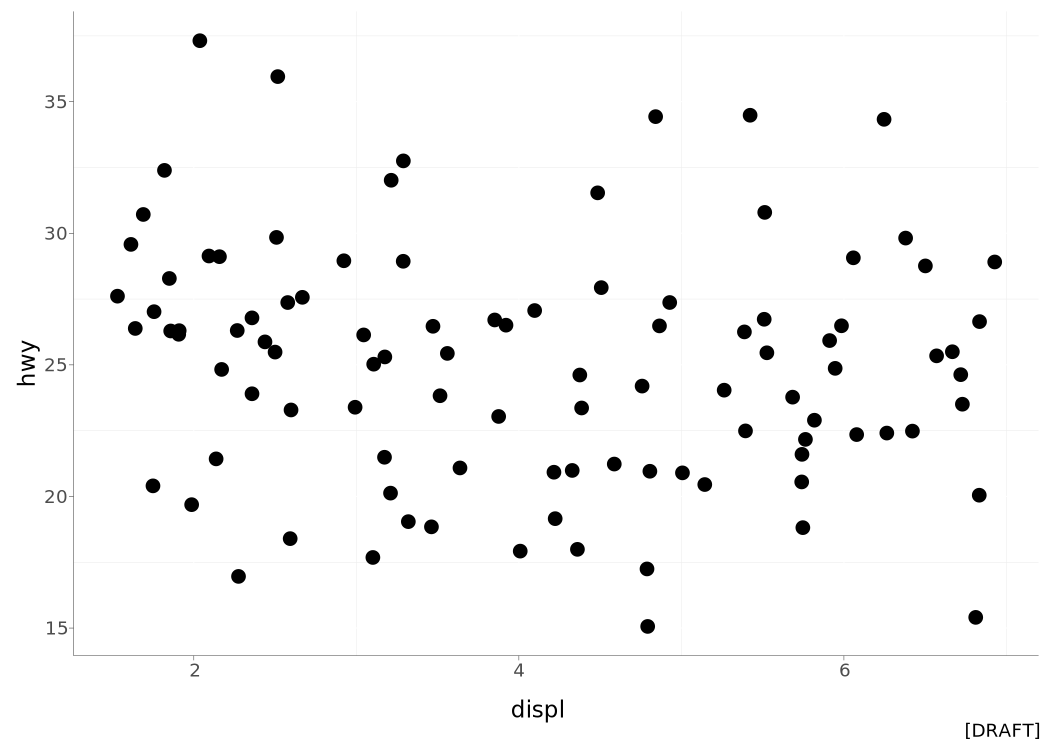

In [4]:
class Watermark:
    """A simple component that stamps text into the plot's caption."""
    def __init__(self, text: str):
        self.text = text


@update_ggplot.register(Watermark)
def _add_watermark(obj, plot, object_name=""):
    """When a Watermark is added via +, inject its text as a caption."""
    plot.labels["caption"] = f"[{obj.text}]"
    return plot


# Now use it with the + operator
p = (
    ggplot(mpg, aes(x='displ', y='hwy'))
    + geom_point()
    + Watermark("DRAFT")
    + theme_minimal()
)
print("Caption label:", p.labels.get("caption"))
p

## 3. A more complex example: `Subtitle` component

Register a component that modifies the plot subtitle and adds a visual marker.

Subtitle: >>> Engine size vs fuel economy


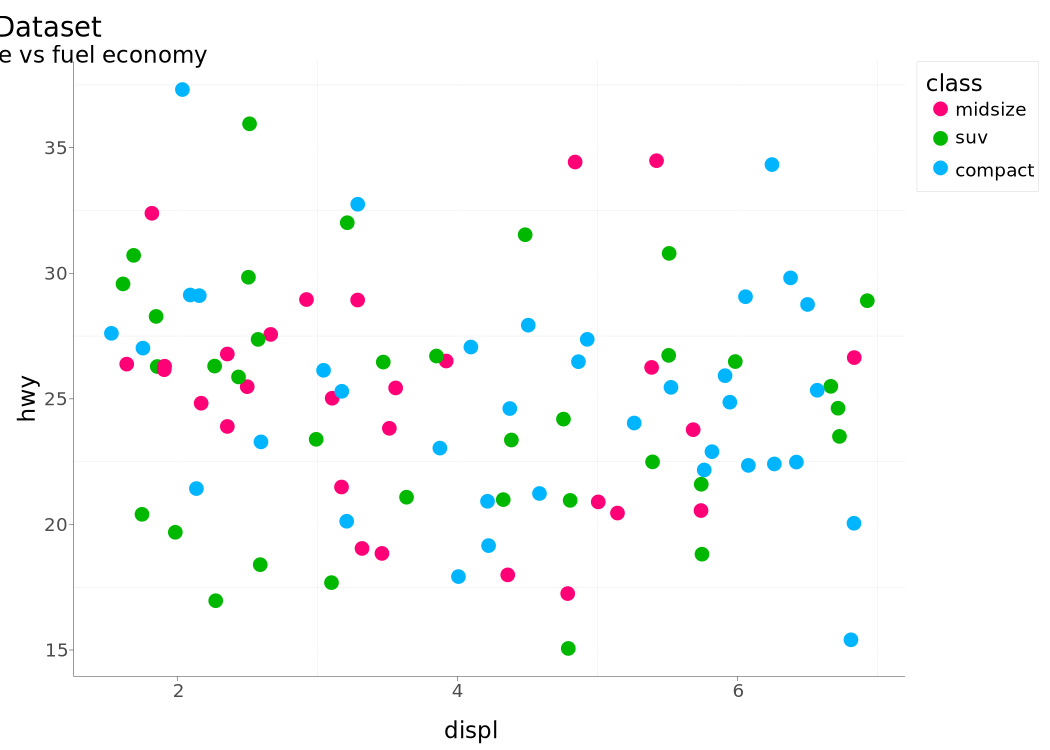

In [5]:
class Subtitle:
    """Adds a styled subtitle with an optional prefix marker."""
    def __init__(self, text: str, marker: str = ">>>"):
        self.text = text
        self.marker = marker


@update_ggplot.register(Subtitle)
def _add_subtitle(obj, plot, object_name=""):
    plot.labels["subtitle"] = f"{obj.marker} {obj.text}"
    return plot


p = (
    ggplot(mpg, aes(x='displ', y='hwy', colour='class'))
    + geom_point()
    + Subtitle("Engine size vs fuel economy")
    + labs(title='MPG Dataset')
    + theme_minimal()
)
print("Subtitle:", p.labels.get("subtitle"))
p

## 4. `by_layer()` --- applying operations per-layer

The build pipeline uses `by_layer(fn, layers, data, step)` to apply a function
to each layer's data in parallel. It provides:
- Per-layer error reporting (tells you which layer failed)
- Consistent list-in / list-out semantics

You can use it in custom pipeline extensions.

In [6]:
# Simulate by_layer usage
# Create mock "layers" and per-layer data
class MockLayer:
    def transform(self, df):
        return df.assign(hwy_scaled=df['hwy'] / df['hwy'].max())

layers = [MockLayer(), MockLayer()]
data = [mpg.head(50), mpg.tail(50)]

# by_layer applies fn(layer_i, data_i) for each pair
result = by_layer(
    fn=lambda layer, d: layer.transform(d),
    layers=layers,
    data=data,
    step="scaling highway values",
)

print(f"Layer 0 result columns: {list(result[0].columns)}")
print(f"Layer 1 shape: {result[1].shape}")

Layer 0 result columns: ['displ', 'hwy', 'cyl', 'class', 'hwy_scaled']
Layer 1 shape: (50, 5)


## 5. When and why to register custom types

Use `@update_ggplot.register(MyClass)` when:

- You are building an **extension package** that adds new plot components.
- You want a domain-specific shortcut (e.g., `+ BrandTheme()`).
- You want to inject metadata (annotations, watermarks, data sources) cleanly.

Do **not** register custom types for things that already have a natural
ggplot2 representation (scales, coords, themes, layers).

## 6. Comparison: R's S3/S7 vs Python's singledispatch

| Feature | R (S3/S7) | Python (singledispatch) |
|---|---|---|
| Registration | `ggplot_add.MyClass <- function(...)` | `@update_ggplot.register(MyClass)` |
| Dispatch on | First argument class | First argument class |
| Introspection | `methods(ggplot_add)` | `update_ggplot.registry.keys()` |
| Inheritance | Walks MRO | Walks MRO |
| Multi-dispatch | S7 supports it | Not built-in (use `dispatch` from `plum`) |
| Namespace | Registered in package namespace | Registered at module import |

The key advantage: in Python, registration is explicit and discoverable via
the `.registry` attribute. No hidden method tables.